# Lecture 5

## Test Feb. 12

- **Length:** 90 minutes: 4:10PM - 5:40PM
- **Location:** [Lash Miller Chemical Labs](https://map.utoronto.ca/?id=1809#!m/494502?share), Rooms: LM 121A and 121B (computer lab)

![](LM121-01.jpeg)

- **Coverage:** All material up to and including this lecture (Feb. 5).
- **Format:** You will complete the test on a computer using a Jupyter notebook on the UofT Jupyterhub. The structure of the test will be similar to the homeworks you have been completing.  The test will be submitted to MarkUs for grading.  Autotesting will not be enabled.
- **Materials allowed:**
    * You will have access to the course website, course notebooks on your Jupyterhub account (lectures, labs, homeworks), and ceratin websites that contain pytho (pandas, sklearn, etc. documentation).
    * You will **not** have access to web search or generative AI tools (e.g., ChatGPT).

## Class vote on marking scheme change



## Today's Class

By the end of this class, you will be able to…
- Explain supervised vs. unsupervised learning and identify logistic regression and classification trees as supervised methods.
- Describe how a classification tree makes predictions using a sequence of splits and leaf (terminal) nodes.
- Define impurity and interpret Gini impurity values shown in a tree node (e.g., what “gini = 0.471” means).
- Compute and interpret impurity decrease and explain how it drives split selection (why a tree chooses one split over another).
- Interpret a fitted tree’s output: depth, number of leaves, split rules, class proportions (value), predicted class, and feature importances.
- Use scikit-learn to fit and visualize a tree, including setting key parameters like max_depth and plotting with `plot_tree`.
- Explain how split thresholds are chosen (midpoints between observed feature values at a node).
- Generate and interpret predicted probabilities with `predict_proba`, and apply a custom classification threshold.
- Evaluate a tree classifier on a test set using confusion matrices, accuracy, precision, recall, F1, specificity, and interpret these in terms of TP/FP/TN/FN.
- Create and interpret an ROC curve and AUC, and explain how varying the probability threshold changes TPR and FPR.
- Compare a decision tree to logistic regression using test-set metrics and explain tradeoffs (e.g., higher recall vs. fewer false positives).

## Employment after graduation 

- What can universities do to support employment of recent university graduates?  

![](employmentscreenshot.png)

## What should universities do?

- Host career/internship fairs
- Collect data on students
- Talk to students about thier experience
  

## Data on grad employment

A simulated data for 5,000 recent graduates with four predictors that are easy to interpret is in `grademployment.csv`: 

- employed_6months = 1 means the graduate found a job within 6 months; 0 means they did not.
- CGPA,
- internship experience (0/1),
- parents’ socioeconomic status (1–3), and
- extracurricular involvement (0/1).

## Classification/Decision Trees

- A classification tree is like a flowchart for making a yes/no (or multiple-choice) decision.
- You start at the top (*viz. root node*) with a question about the thing you’re trying to classify (for example: “Did the student have an internship during university?”).
- Depending on the answer, you *follow a branch* to the next question (*viz. internal/split/decision node*) (“Do they have a good CGPA?”), and keep going until you reach an endpoint (*viz. leaf node*).
- That endpoint is the tree’s final decision, like “likely to be employed after graduation” or “unlikely to to be employed after graduation.”
- The tree **learns** which questions to ask by looking at past examples and picking questions that separate the groups (e.g., employed or unemployed after graduation) as clearly as possible—in other words, questions that help make the outcome more obvious.

## Supervised and Unsupervised Learning

- **Supervised learning** is used when you have inputs (features) and a known target label/outcome for each example. The goal is to learn a rule that can predict the outcome for new data.

  
	*	Example task: predicting employed within 6 months (yes/no) from CGPA, internship, etc.
	*	Logistic regression is a supervised learning method for binary outcomes. It learns how each feature changes the probability of class 1 (e.g., employed).

- **Classification trees** are also supervised learning. They learn a sequence of if–then splits (questions like “Internship = yes?”) to predict the class label (and often a probability).


- **Unsupervised learning** is used when you have inputs only and no labeled outcome. The goal is to find patterns or structure in the data.
	* Examples: grouping students into “similar profiles” using clustering, or reducing many variables into a few summary dimensions using PCA.

## Explore employment data

In [72]:
# Simulated Example: Predicting Employment After Graduation
import pandas as pd

grad_df = pd.read_csv('grademployment.csv')
grad_df.head()

,Unnamed: 0,cgpa,internship,parents_ses,extracurriculars,employed_6months
0,0,2.75,0,2,1,1
1,1,3.90,1,2,1,1
2,2,3.46,1,1,1,1
3,3,3.20,0,2,0,1
4,4,2.31,1,2,0,0


In [69]:
cat_cols = ['internship', 'parents_ses', 'extracurriculars']

for c in cat_cols:
    out = (grad_df[c]
           .value_counts(dropna=False)
           .to_frame("count"))
    out["percent"] = (out["count"] / out["count"].sum() * 100).round(1)
    print(f"\n{c}")
    print(out)

grad_df['cgpa'].describe()


internship
            count  percent
internship                
1            2975     59.5
0            2025     40.5

parents_ses
             count  percent
parents_ses                
2             2466     49.3
1             1503     30.1
3             1031     20.6

extracurriculars
                  count  percent
extracurriculars                
1                  3332     66.6
0                  1668     33.4


count    5000.000000
mean        2.993562
std         0.579347
min         2.000000
25%         2.490000
50%         3.000000
75%         3.500000
max         4.000000
Name: cgpa, dtype: float64

## Employment within 6 months by internship and extracurriculars

In [70]:
rate = (grad_df
        .groupby(["internship", "extracurriculars"])["employed_6months"]
        .mean()
        .rename("employment_rate"))
print(rate)

internship  extracurriculars
0           0                   0.316493
            1                   0.416420
1           0                   0.553769
            1                   0.646465
Name: employment_rate, dtype: float64


**Takeaway:**

- Employment rates rise with both internships and extracurriculars
- lowest for no internship + no extracurriculars (~31.6%),
- higher with extracurriculars only (~41.6%),
- higher with internship only (~55.4%), and
- highest with both (~64.6%).

## Classification Trees

- Split the data into features/covariates `X` that will be used to predict the target/outcome/dependent variable `y`.
- Then split this further into training and test sets using `train_test_split` from `sklearn.model_selection`.

In [67]:
from sklearn.model_selection import train_test_split

# Split into training (80%) and test (20%) sets
X = grad_df[['cgpa', 'internship', 'parents_ses', 'extracurriculars']]
y = grad_df['employed_6months']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
grad_df.head(10)

Training set size: 4000
Test set size: 1000


,Unnamed: 0,cgpa,internship,parents_ses,extracurriculars,employed_6months
0,0,2.75,0,2,1,1
1,1,3.90,1,2,1,1
2,2,3.46,1,1,1,1
3,3,3.20,0,2,0,1
4,4,2.31,1,2,0,0
5,5,2.31,0,3,0,0
6,6,2.12,1,1,0,1
7,7,3.73,1,2,1,1
8,8,3.20,0,2,1,1
9,9,3.42,1,2,0,1


### build and fit the classifier using `DecisionTreeClassifier`

- `criterion='gini'`: Tells the tree how to choose splits. It picks the split that reduces Gini impurity the most (makes the child nodes more “pure”).
  
- `max_depth=3`: Limits the tree to at most 3 levels of splits from the root. This keeps the tree simple and helps prevent overfitting.

- `min_samples_split=10`: A node must have at least 10 samples to be allowed to split. 

- `min_samples_leaf=10`: After a split, each child node must contain at least 10 samples. This prevents the tree from creating tiny leaves based on very few observations (which are often unreliable).

In [73]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

import matplotlib.pyplot as plt


# Build decision tree on training data
dt_clf = DecisionTreeClassifier(criterion='gini', 
                                max_depth=3, 
                                min_samples_split=10, 
                                min_samples_leaf=10)
dt_clf.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curren

## Display the classification tree

 Classification trees can be displayed using `export_tree` or `plot_tree` from [`sklearn.tree`](https://scikit-learn.org/stable/modules/generated/sklearn.tree.plot_tree.html)

 ### `export_tree`

In [27]:
print(export_text(dt_clf, feature_names=list(dt_clf.feature_names_in_)))

|--- internship <= 0.50
|   |--- cgpa <= 3.08
|   |   |--- extracurriculars <= 0.50
|   |   |   |--- class: 0
|   |   |--- extracurriculars >  0.50
|   |   |   |--- class: 0
|   |--- cgpa >  3.08
|   |   |--- parents_ses <= 1.50
|   |   |   |--- class: 0
|   |   |--- parents_ses >  1.50
|   |   |   |--- class: 0
|--- internship >  0.50
|   |--- cgpa <= 3.10
|   |   |--- extracurriculars <= 0.50
|   |   |   |--- class: 0
|   |   |--- extracurriculars >  0.50
|   |   |   |--- class: 1
|   |--- cgpa >  3.10
|   |   |--- cgpa <= 3.45
|   |   |   |--- class: 1
|   |   |--- cgpa >  3.45
|   |   |   |--- class: 1



### Tree structure

- We can investigate the tree structure using the following: `get_depth`, `get_n_leaves`, `n_features_in_`, `feature_names_in`, and `classes_` (see [DecisionTreeClassifier documentation](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html?utm_source=chatgpt.com#sklearn.tree.DecisionTreeClassifier.get_depth))

In [28]:
# Tree structure
print(f"Tree depth: {dt_clf.get_depth()}")
print(f"Number of leaves: {dt_clf.get_n_leaves()}")
print(f"Number of features: {dt_clf.n_features_in_}")
print(f"Feature names: {list(dt_clf.feature_names_in_)}")
print(f"Classes: {dt_clf.classes_}")

Tree depth: 3
Number of leaves: 8
Number of features: 4
Feature names: ['cgpa', 'internship', 'parents_ses', 'extracurriculars']
Classes: [0 1]


### `plot_tree`

- `plot_tree` displays a tree with most of this information
- Define plotting region using `matplotlib.pyplot` (not necessary but makes output nicer)

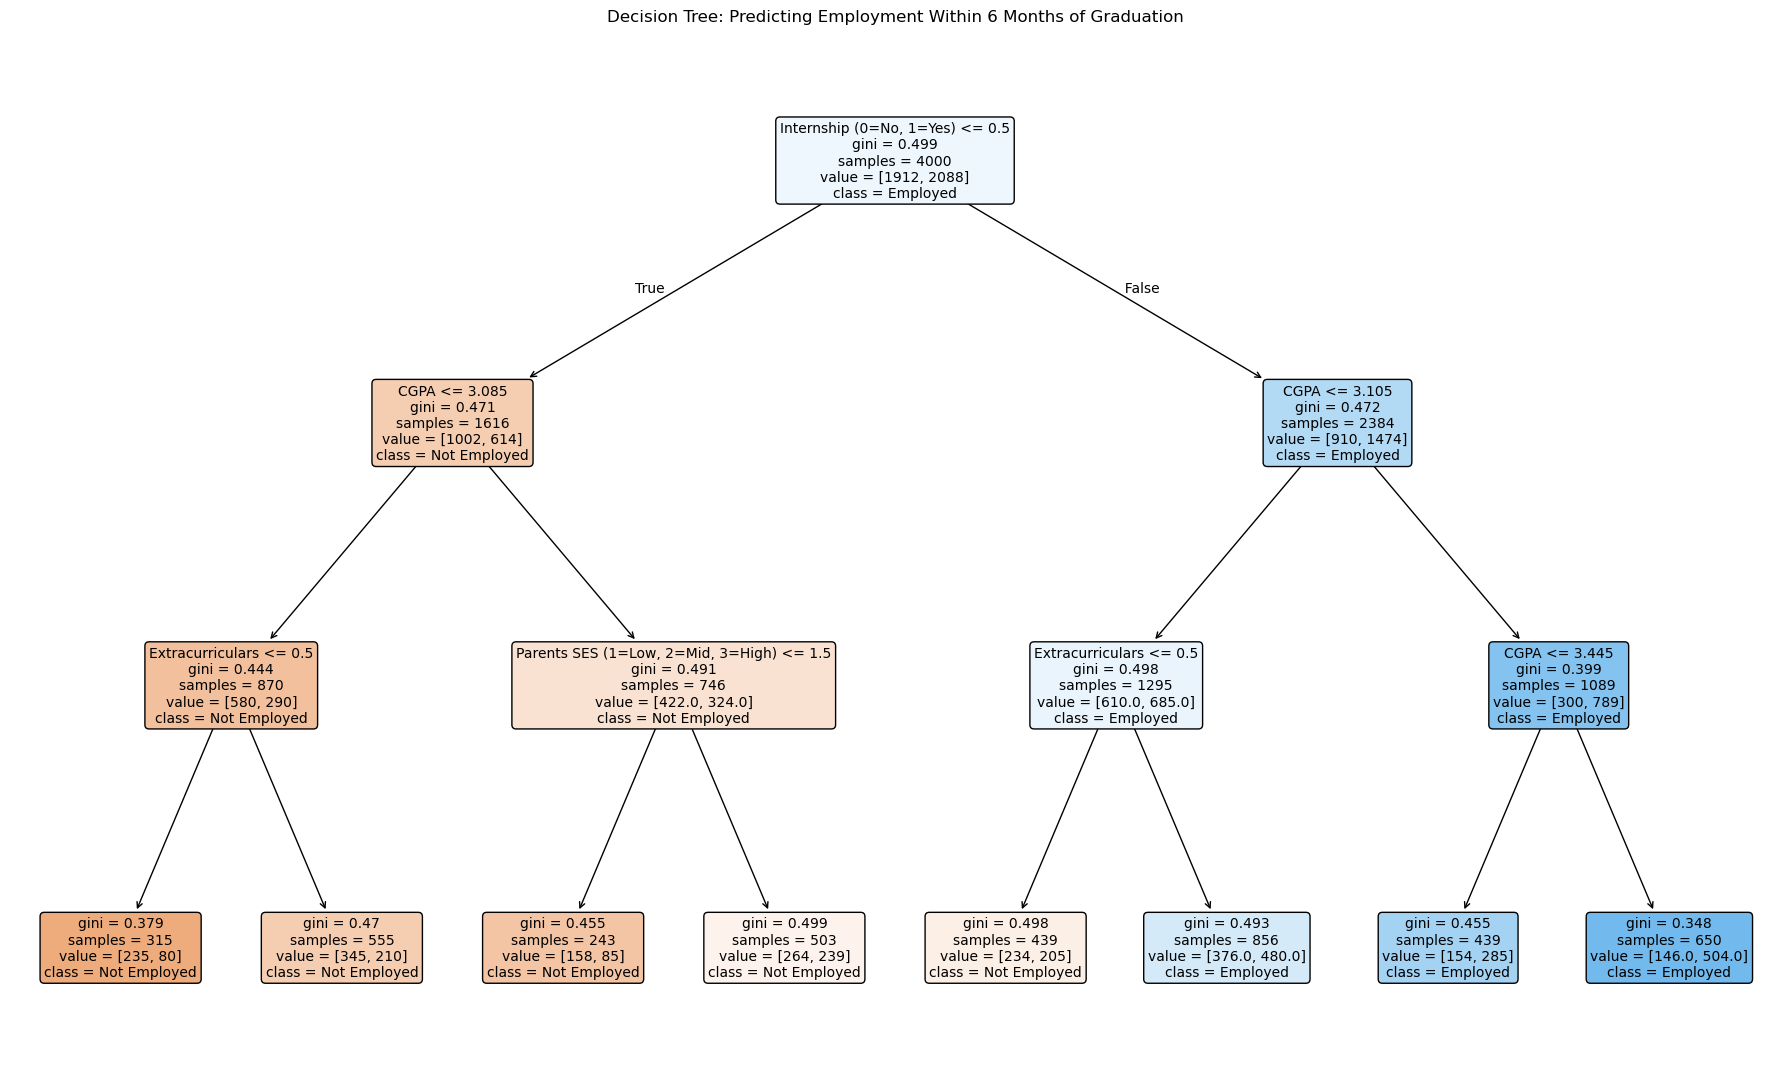

In [29]:
import matplotlib.pyplot as plt

#Plot the decision tree
plt.figure(figsize=(18, 11))
plot_tree(dt_clf, 
          feature_names=['CGPA', 'Internship (0=No, 1=Yes)', 'Parents SES (1=Low, 2=Mid, 3=High)', 'Extracurriculars'],
          class_names=['Not Employed', 'Employed'],
          filled=True, 
          rounded=True,
          proportion=False,
          fontsize=10)
plt.title('Decision Tree: Predicting Employment Within 6 Months of Graduation')
plt.tight_layout()
plt.show()

## How to read the tree classifier diagram

- Each line is a yes/no question.
- <= 0.50 is how sklearn writes a binary variable split (so it basically means “0 vs 1”).
- internship <= 0.50 ≈ no internship
- internship > 0.50 ≈ has internship
- The tree follows a path until it reaches class: 0 or class: 1 (its final prediction)

![](decision_tree_annotated_readable_v2.png)

## How does the tree choose splits?

- In selecting a good feature to split on the tree classifier algorithm considers all the features and measures how well each feature splits people into not employed or employed. 
- Once a good split is found then a search is made for good splits of the two descendant splits.
- The idea is finding splits of internal nodes so as to give **"purer"** descendant nodes.

## Gini Index: How mixed are classes in a node?

- Proposed by [Corrado Gini](https://en.wikipedia.org/wiki/Gini_coefficient) as a measure of inequality of income around 1912. 

- The gini index $G$ measures node impurity: $G(t) =2p(1-p),$ where $p$ is the proportion of students in class 1 (and $1-p$ in class 0).

- This is the default criterion in `DecisionTreeClassifier` (i.e., `criterion='gini'`).  

- When $G=0$ then the node is pure (i.e., all samples have the same class), when $G=0.5$ then it is mixed (50/50 employed/unemployed)

- Roughly speaking:

    * Low gini (e.g., 0.05–0.20): the node is mostly one class → the tree is confident there.
	*	Medium gini (e.g., 0.25–0.40): some mixing → less confident.
	*	High gini (near 0.5 in binary): very mixed → the tree really benefits from further splitting (if possible).


## Entropy and Log loss

Other criterion in `DecisionTreeClassifier` are `criterion = 'entropy'` and `criterion = 'log_loss'`).

- Gini and entropy usually pick very similar splits. 

- Log loss is a good choice when the user cares about good probability estimates, not just final class label.

## If we choose a different criterion to split on will the tree be different?

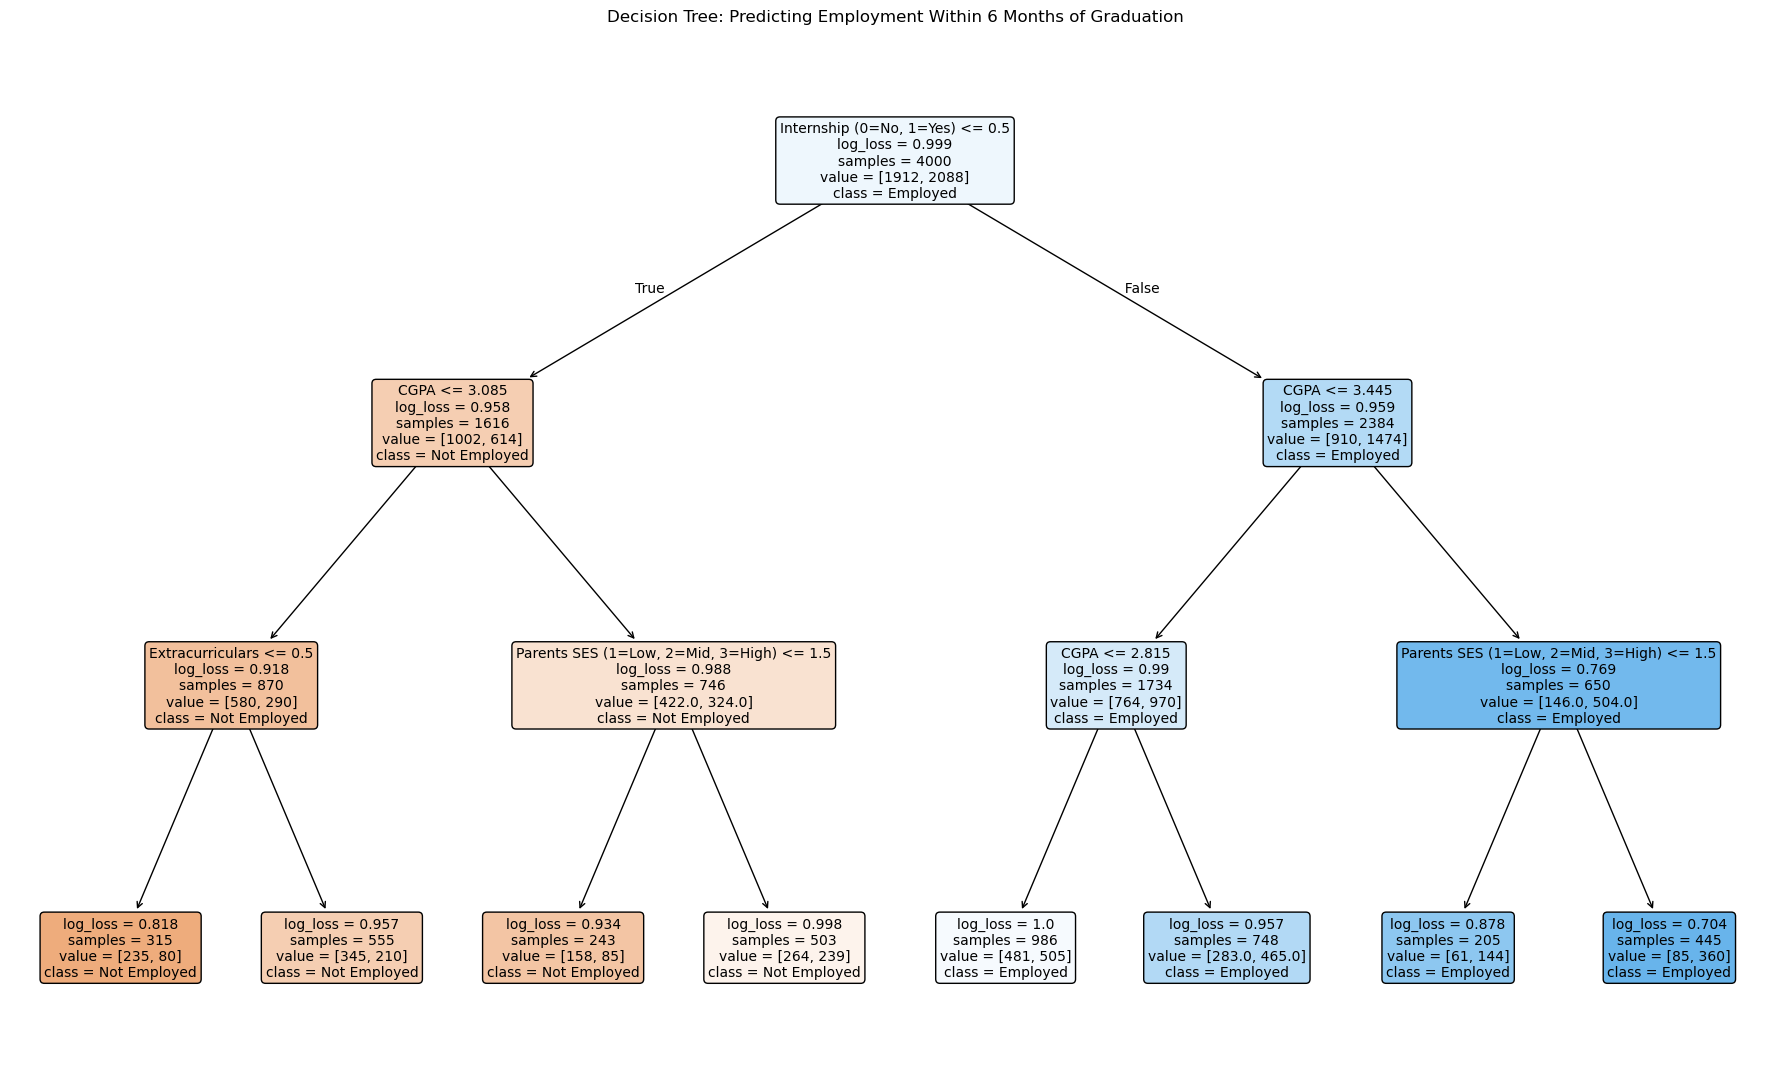

In [30]:
tree_entropy = DecisionTreeClassifier(criterion='log_loss', max_depth=3, min_samples_split=10, min_samples_leaf=10 )

tree_entropy.fit(X_train, y_train)

plt.figure(figsize=(18, 11))
plot_tree(tree_entropy, 
          feature_names=['CGPA', 'Internship (0=No, 1=Yes)', 'Parents SES (1=Low, 2=Mid, 3=High)', 'Extracurriculars'],
          class_names=['Not Employed', 'Employed'],
          filled=True, 
          rounded=True,
          proportion=False,
          fontsize=10)
plt.title('Decision Tree: Predicting Employment Within 6 Months of Graduation')
plt.tight_layout()
plt.show()

## Impurity: How does the tree decide which feature to split on?

- A node is most impure when all the classes are mixed together and most pure when there is only one class.

- The change in impurity $\Delta$ measures how much the impurity of a candidate split decreases the impurity (i.e., separates the classes of not epmployed and employed or becomes more "pure")

- $\Delta \mathrm{gini}\;=\;\mathrm{gini}(t)\;-\;\left(\frac{n_L}{n}\,\mathrm{gini}(t_L)+\frac{n_R}{n}\,\mathrm{gini}(t_R)\right),$ where $t_L, t_R$ are the left/right nodes, $n$ is the number of samples at node $t$, and $n_L,n_R$ are the samples sent to each child node.


## Examining Impurity

In [31]:
# Access the underlying Tree object that stores the learned structure
# (children pointers, feature used at each split, thresholds, impurities, etc.)
tree = dt_clf.tree_
left = tree.children_left
right = tree.children_right

# Use weighted counts so it works even if you used class_weight/sample_weight
n = tree.weighted_n_node_samples
g = tree.impurity

delta = np.zeros(tree.node_count)

for i in range(tree.node_count):
    if left[i] == -1:  # leaf
        continue
    L, R = left[i], right[i]
    delta[i] = g[i] - (n[L]/n[i]) * g[L] - (n[R]/n[i]) * g[R]

# delta[i] is the impurity decrease produced by the split at node i (0 for leaves)

# Get the feature names in the same order as the columns used to train the model
feature_names = list(dt_clf.feature_names_in_)

# Identify which nodes are *split (internal) nodes*:
# in sklearn, a node is a leaf if children_left == -1 (and children_right == -1).
# So left != -1 means "this node actually splits."
split_nodes = np.where(left != -1)[0]

# Rank the split nodes by impurity decrease (delta) from largest to smallest.
# np.argsort gives ascending order, so [::-1] reverses to descending.
ranked = split_nodes[np.argsort(delta[split_nodes])[::-1]]

# Print the top 10 most "impactful" splits (largest impurity decrease)
for i in ranked[:10]:
    # Which feature index was used for splitting at node i, mapped back to its name
    feat = feature_names[tree.feature[i]]

    # The threshold used for that feature at node i (rule is: feat <= thr goes left)
    thr = tree.threshold[i]

    # Print a readable summary:
    # - node id
    # - split rule (feature <= threshold)
    # - Δimpurity: how much impurity decreased because of this split
    # - gini: impurity of the parent node before splitting
    # - n: number of (weighted) samples reaching this node
    print(
        f"node {i:>2}: {feat} <= {thr:.3f} | "
        f"Δimpurity={delta[i]:.4f} | gini={g[i]:.3f} | n={n[i]:.0f}"
    )

node  0: internship <= 0.500 | Δimpurity=0.0274 | gini=0.499 | n=4000
node  8: cgpa <= 3.105 | Δimpurity=0.0190 | gini=0.472 | n=2384
node 12: cgpa <= 3.445 | Δimpurity=0.0077 | gini=0.399 | n=1089
node  2: extracurriculars <= 0.500 | Δimpurity=0.0072 | gini=0.444 | n=870
node  5: parents_ses <= 1.500 | Δimpurity=0.0069 | gini=0.491 | n=746
node  1: cgpa <= 3.085 | Δimpurity=0.0051 | gini=0.471 | n=1616
node  9: extracurriculars <= 0.500 | Δimpurity=0.0039 | gini=0.498 | n=1295


### What if we change `min_impurity_decrease`?

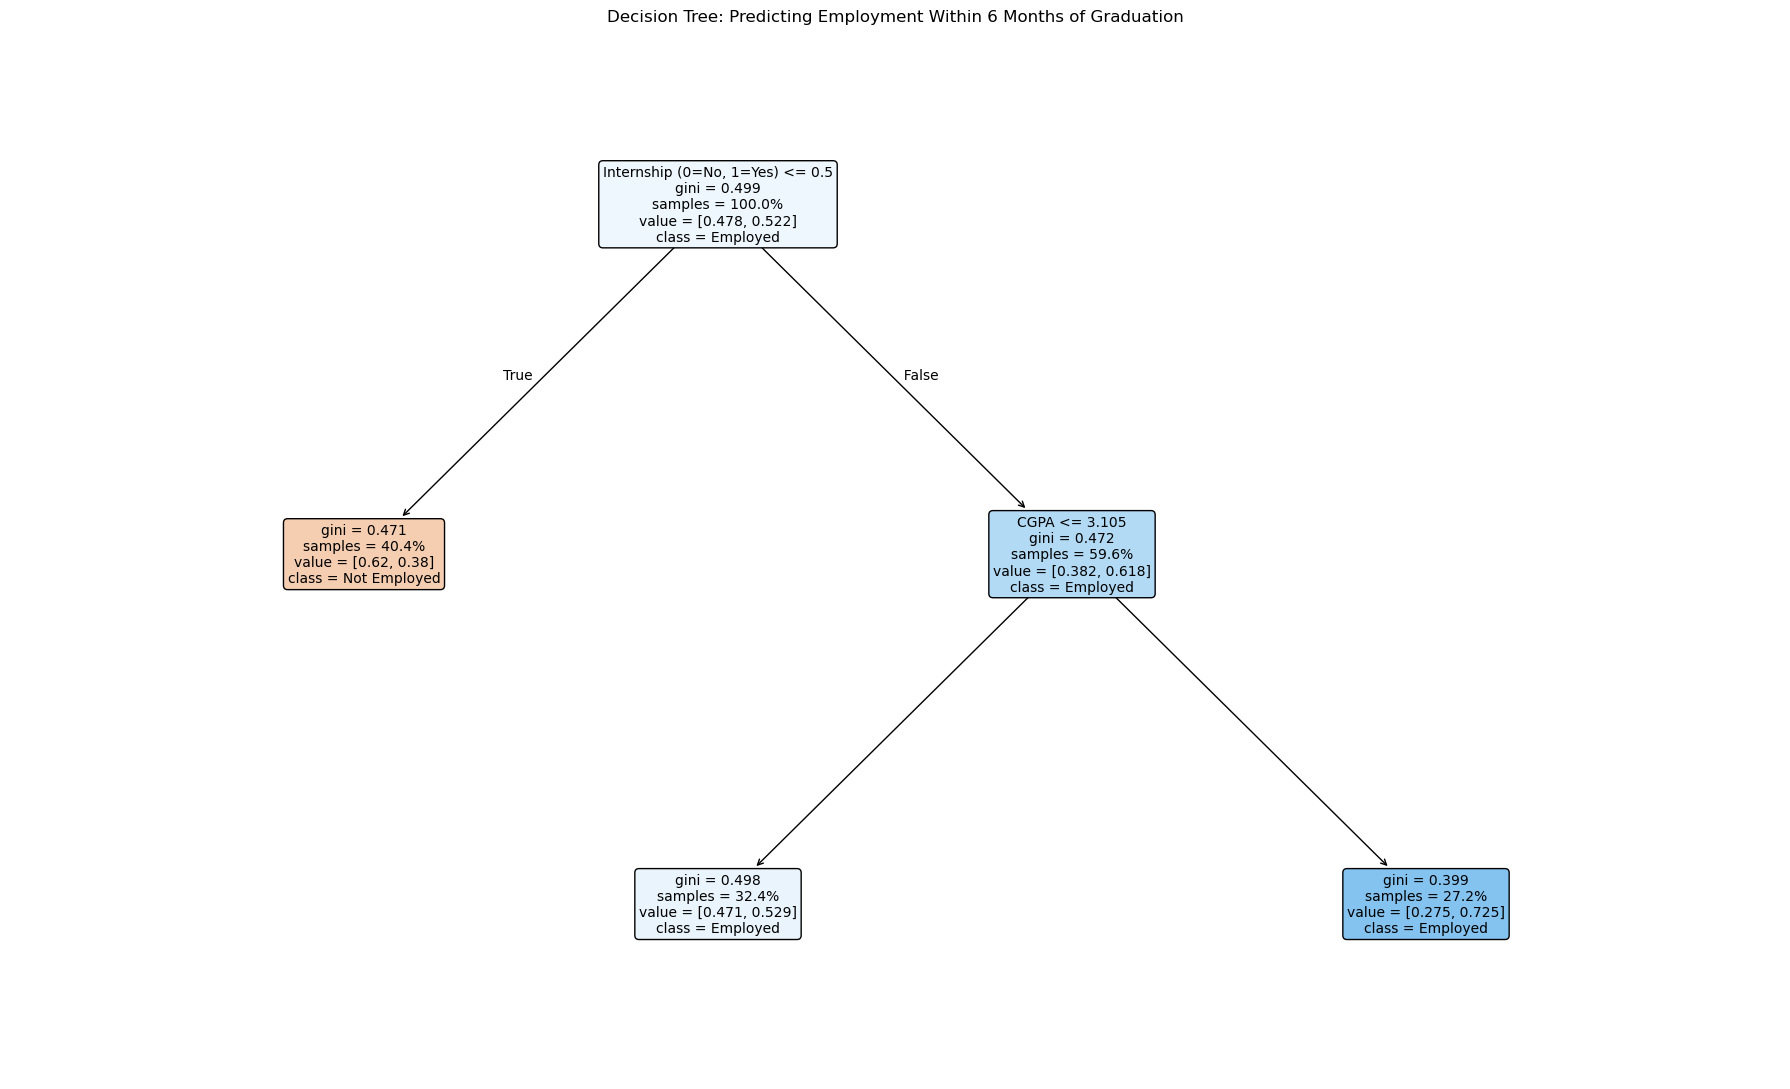

In [32]:
tree_entropy = DecisionTreeClassifier(criterion='gini', max_depth=3, min_samples_split=10, min_samples_leaf=10, min_impurity_decrease=0.01 )

tree_entropy.fit(X_train, y_train)

plt.figure(figsize=(18, 11))
plot_tree(tree_entropy, 
          feature_names=['CGPA', 'Internship (0=No, 1=Yes)', 'Parents SES (1=Low, 2=Mid, 3=High)', 'Extracurriculars'],
          class_names=['Not Employed', 'Employed'],
          filled=True, 
          rounded=True,
          proportion=True,
          fontsize=10)
plt.title('Decision Tree: Predicting Employment Within 6 Months of Graduation')
plt.tight_layout()
plt.show()

## Algorithm for evaluating a given feature at a node: 

1. Look only at the training samples that reached the node.

2.	Take that feature’s ($x$) values and sort them.

3.	The threshold $t$ is the midpoints between consecutive unique sorted values of a feature (if a feature is coded as 0/1, the midpoint becomes 0.5, corresponding to 0 vs 1)

4.	For each threshold $t$, split the node into
	 * left: $x \le t$
	 * right: $x > t$

5.	Compute the impurity decrease (e.g., with Gini), and keep the best threshold for that feature.

6.	Repeat for every feature; choose the feature and threshold with the largest impurity decrease.

## Why do some thresholds look "odd"?

- Because they’re often midpoints.

- For example: if the best separation is between CGPA values 3.08 and 3.09, sklearn will use (3.08+3.09)/2 = 3.085.

## When should the tree algorithm stop splitting?

How does the algorithm decide when the to declare a node terminal (i.e., a leaf node) or to continue splitting?

1. The node is already “pure”

All samples at the node are the same class → impurity is 0 → no useful split.*(e.g., gini = 0.0 (or entropy = 0))

2. No split can improve impurity enough

Even if the node is mixed, the best possible split doesn’t reduce impurity by a meaningful amount.
  * Controlled by: min_impurity_decrease (default 0.0)

3. The node has too few samples to split
	* min_samples_split: need at least this many samples in the node to even attempt a split.
	* min_samples_leaf: after a split, each child must have at least this many samples (otherwise that split is rejected).

4. You hit the maximum allowed size of the tree
	* max_depth: if the node is already at the maximum depth, it becomes a leaf.
	* max_leaf_nodes: if you already have enough leaves, you stop creating more.

5. No valid split exists

    * For example, if every feature has the same value for all samples at that node, you can’t separate anything.


## Stop splitting

The tree keeps splitting as long as it can make the groups meaningfully cleaner and it’s allowed to grow. If it’s already pure, too small, out of depth, or no split improves things, it stops and declares a leaf.

## How is each terminal node assigned to a class?

### Conceptual idea
1. Collect all training points that reach the leaf.
2. Count how many are in each class (using sample weights / class weights if you provided them).
3. Turn those counts into probabilities:


### Mathematical idea

Let $n_0$ be the number of training cases in the leaf with class $0$, and let $n_1$ be the number of training cases in the leaf with class $1$. Then the probabilities of class 0 ($\hat p_0(\text{leaf})$) and class 1 ($\hat p_1(\text{leaf})$) are:
$$
\hat p_0(\text{leaf}) = \frac{n_0}{n_0+n_1}, \qquad
\hat p_1(\text{leaf}) = \frac{n_1}{n_0+n_1}.
$$

The leaf's predicted class is the largest of these two probabilities.

## Evaluating a Tree Classifier

 Tree classifiers output a probability between 0 and 1 at each terminal node. 
   * If the predicted probability of employment (class 1) $\ge 0.5$ then predict class 1 (employed)
   * If the predicted probability of employment (class 1) $< 0.5$ then predict 0 (unemployed)

## Predicted Probabilities

- [`predict_proba(X)`](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html#sklearn.tree.DecisionTreeClassifier.predict_proba) - Predict class probabilities of the input samples X. 
- This means we plug-in the values of `cgpa`, `internship`, `parents_ses`, `extracurriculars` for an observation in `X` into the tree we trained on `X_train` and to compute the probability that this person will be employed.
- 

In [33]:
# first row of test set
X_test[:1]

,cgpa,internship,parents_ses,extracurriculars
1501,2.96,0,3,1


In [34]:
p = dt_clf.predict_proba(X_test[:1])

# p[0,0] is predicted prob of class 0 and p[0,1] is predicted prob of class 1

print(' The predicted probability of unemployment (class 0) is',round(p[0,0],2), '\n',
      'The predicted probability of employment (class 1) is',round(p[0,1],2), '\n'
      ' The predicted class is',int(p[0,1] > 0.5))

 The predicted probability of unemployment (class 0) is 0.62 
 The predicted probability of employment (class 1) is 0.38 
 The predicted class is 0


The probability that a student with cgpa = 2.96, no internship, parents_ses = 3, extracurriculars = 1 will be employment within 6 months of graduation is 38%.  The predicted class will unemployed. 

## Choosing a custom probability threshold

- Sometimes we may want to change the threshold probability that is used to classify an observation as class 1.
- Create a Boolean variable based on the predicted probabilty by greater than or equal to the threshold value then cast the Boolean value to 0 (False)/ 1 (True)

In [35]:
# Probabilities on new data / test data
p1 = dt_clf.predict_proba(X_test)[:, 1]   # P(class=1)

# Choose a custom threshold (default is effectively 0.5 for binary)
threshold = 0.50
y_pred_custom = (p1 >= threshold).astype(int)


## Evaluating classification accuracy

We can use the same accuracy metrics that were used for logistic regression.

TP (true positives): predicted 1 and actually 1
TN (true negative): predicted 0 and actually 0
FP (false positives): predicted 1 but actually 0
FN (false negatives): predicted 0 but actually 1

**Confusion Matrix**

$$
\begin{array}{c|cc|c}
 & \text{Predicted }0 & \text{Predicted }1 & \text{Row total} \\
\hline
\text{Actual }0 & \mathrm{TN} & \mathrm{FP} & \mathrm{TN}+\mathrm{FP} \\
\text{Actual }1 & \mathrm{FN} & \mathrm{TP} & \mathrm{FN}+\mathrm{TP} \\
\hline
\text{Column total} & \mathrm{TN}+\mathrm{FN} & \mathrm{FP}+\mathrm{TP} & \mathrm{TN}+\mathrm{FP}+\mathrm{FN}+\mathrm{TP}
\end{array}
$$

**Precision**

“Of the things I predicted as positive, how many were truly positive?”
$$\text{Precision}=\frac{TP}{TP+FP}$$
High precision = few false alarms.

**Recall/Sensitivity/True Positive Rate**

“Of the truly positive things, how many did I catch?”
$$\text{Recall}=\frac{TP}{TP+FN}$$
High recall = few missed positives.

**F1 score**

A single number that balances precision and recall (their harmonic mean):
$$F1 = \frac{2\,(\text{Precision})(\text{Recall})}{\text{Precision}+\text{Recall}}$$
F1 is high only if both precision and recall are reasonably high.

**Specificity (True Negative Rate)**

$$\text{Specificity}=\frac{TN}{TN+FP}$$
Meaning: “Of the truly negative cases, how many did I correctly label as negative?”

accuracy_score: the fraction of predictions your model got correct.

$$\text{Accuracy}=\frac{\#\text{ correct predictions}}{\#\text{ total predictions}}
=\frac{TP+TN}{TP+TN+FP+FN}.$$



## Confusion Matrix for Classification Tree

In [36]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = dt_clf.predict(X_test)

print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred_custom))


Confusion matrix:
 [[322 159]
 [214 305]]


The confusion matrix is:

$$
\begin{array}{c|cc}
 & \text{Predicted }0 & \text{Predicted }1 \\
\hline
\text{Actual }0 & 322 & 159 \\
\text{Actual }1 & 214 & 305
\end{array}
$$

**Class 0 metrics (treat “0” as the class of interest)**

Recall for class 0 (how many actual 0’s you correctly caught): $\text{Recall}_0=\frac{TN}{TN+FP}=\frac{322}{322+159}=\frac{322}{481}=0.669$

Meaning: 66.9% of true class 0 were predicted as 0.


Precision for class 0 (when you predict 0, how often you’re right): $\text{Precision}_0=\frac{TN}{TN+FN}=\frac{322}{322+214}=\frac{322}{536}=0.601$

Meaning: Of the 536 predictions of 0, 60.1% were correct.

**Class 1 metrics**

Recall for class 1: $\text{Recall}_1=\frac{TP}{TP+FN}=\frac{305}{305+214}=\frac{305}{519}=0.588$

Meaning: 58.8% of true class 1 were correctly predicted as 1.

Precision for class 1: $\text{Precision}_1=\frac{TP}{TP+FP}=\frac{305}{305+159}=\frac{305}{464}=0.657$

Meaning: Of the 464 predictions of 1, 65.7% were correct.

**Accuracy**

$\text{Accuracy}=\frac{TP+TN}{1000}=\frac{305+322}{1000}=\frac{627}{1000}=0.627$

So the model is correct 62.7% of the time.

## `classification_report` [from sklearn.metrics](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html)

In [37]:
tree_classreport = classification_report(y_test, y_pred_custom, digits=3)

print("\n Classification Report:\n", tree_classreport)


 Classification Report:
               precision    recall  f1-score   support

           0      0.601     0.669     0.633       481
           1      0.657     0.588     0.621       519

    accuracy                          0.627      1000
   macro avg      0.629     0.629     0.627      1000
weighted avg      0.630     0.627     0.627      1000



## Putting it altogether

- Performance is moderate (~63% accuracy).
- The model is a bit better at finding class 0 (higher recall 0.669) than finding class 1 (recall 0.588).
- Predictions of class 1 are somewhat more reliable than predictions of class 0 (precision 0.657 vs 0.601), but it misses a fair number of true class 1s.


## ROC Analysis

- ROC curve illustrates the tradeoff between catching positives and triggering false alarms as you vary the decision threshold on your predicted probabilities.
  
The tree outputs a score $p_1$ = probability of class 1 for each test case. You choose a probability threshold $t$ and classify an observation as:
- 1, if $p_1 \ge t$ and 
- 0, if $p_1 < t$.

* Each point on the ROC curve corresponds to a different threshold and plots:
  * TPR $(True Positive Rate / Recall) =\frac{TP}{TP+FN}$ on the y-axis 
  * FPR $(False Positive Rate) =\frac{FP}{FP+TN}=1-\text{specificity}$ on the x-axis
  
  *	Lowering the threshold predicts “class 1” more often → TPR goes up (catch more positives) but FPR also goes up (more false positives). Raising the threshold does the opposite.
  

For the ROC curve, `sklearn` varies $t$ over many values (based on the unique scores in $p_1$) to trace out different (FPR, TPR) points.

`roc_curve` computes `fpr`, `tpr`, and `thresholds`

## Interpreting ROC values 
- a threshold inf (infinity) means nothing can be greater so the model predicts all 0. 

- a threshold of 0.475149 means the predicted class is 1 if the predicted probability is $\ge$ 0.475149.  

    * In this case the false positive rate (fpr or 1 - specificity) is 0.471933 and true positive rate (tpr or recall/sensitivity) is 0.728324. 

- this means if we pick a threshold of 0.48 then ~47% of negative (unemployed) cases will be classified as positive (employed) and ~73% of true positive cases (employed) will be classified correctly.

In [38]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Probability of the positive class (class 1). Adjust if your positive class is different.
p1 = dt_clf.predict_proba(X_test)[:, 1]

# ROC points
fpr, tpr, thresholds = roc_curve(y_test, p1)

pd.DataFrame({"threshold": thresholds, "fpr": fpr, "tpr": tpr})

,threshold,fpr,tpr
0,inf,0.000000,0.000000
1,0.775385,0.081081,0.229287
2,0.649203,0.118503,0.362235
3,0.560748,0.330561,0.587669
4,0.475149,0.471933,0.728324
5,0.466970,0.627859,0.828516
6,0.378378,0.835759,0.926782
7,0.349794,0.889813,0.965318
8,0.253968,1.000000,1.000000


## ROC Curve

  *	The dashed diagonal line is “random guessing.” Curves closer to the top-left corner mean better discrimination.
  
  *	AUC summarizes the ROC curve into one number: the probability the model gives a higher score to a random positive than a random negative (1.0 is perfect, 0.5 is random).


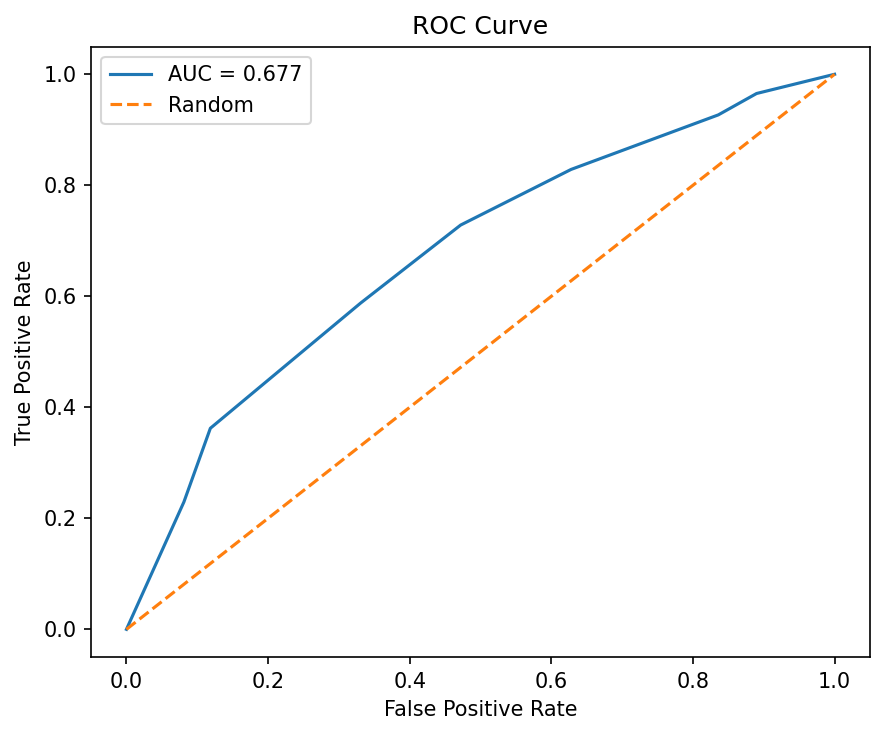

In [39]:
# AUC
auc = roc_auc_score(y_test, p1)

# Plot
plt.figure(figsize=(6, 5), dpi=150)
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

## Compare Decision Tree and Logistic Regression for classification

- Logistic regression can be used to classify students according to employment status.
- If logistic regression is used to build a classifier then how does the accuracy of these models compare.
- We will build a classifier using logistic regression on the training set `X_train, y_train` and test it on the test set `X_test, y_test`.

In [44]:
import statsmodels.api as sm

# add a constant
X_train_with_const = sm.add_constant(X_train)

# fit logistic regression
model = sm.Logit(y_train,X_train_with_const).fit()
# model summary
model.summary()

Optimization terminated successfully.
         Current function value: 0.647292
         Iterations 5


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:       employed_6months   No. Observations:                 4000
Model:                          Logit   Df Residuals:                     3995
Method:                           MLE   Df Model:                            4
Date:                Thu, 05 Feb 2026   Pseudo R-squ.:                 0.06485
Time:                        10:50:31   Log-Likelihood:                -2589.2
converged:                       True   LL-Null:                       -2768.7
Covariance Type:            nonrobust   LLR p-value:                 1.909e-76
====================================================================================
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -2.7883      0.213    -13.080      0.000      -3.206      -2.371
cgpa                 0.5533      0.058      9.578      0.000       0.440       0.667
internship           1.0075      0.068     14.857      0.000       0.875       1.140
parents_ses          0.2059      0.047      4.355      0.000       0.113       0.299
extracurriculars     0.3461      0.070      4.917      0.000       0.208       0.484
====================================================================================
"""

## Compute Logistic Regression Predictions

- Use the test set to compute predicted values.
- Compare these predicted values to observed values.

### compare logistic regression classifier to decision tree classifier

In [47]:
# Make predictions on test set
X_test_const = sm.add_constant(X_test)
y_pred_prob = model.predict(X_test_const)

# Convert probabilities to class predictions (threshold = 0.5)
y_pred = (y_pred_prob >= 0.5).astype(int)

LogisticReg_classreport = classification_report(y_test, y_pred)

# logistic regression classifier
print(LogisticReg_classreport)

              precision    recall  f1-score   support

           0       0.63      0.58      0.61       481
           1       0.64      0.69      0.66       519

    accuracy                           0.64      1000
   macro avg       0.64      0.63      0.63      1000
weighted avg       0.64      0.64      0.63      1000



In [48]:
# decision tree classifier
print(tree_classreport)

              precision    recall  f1-score   support

           0      0.601     0.669     0.633       481
           1      0.657     0.588     0.621       519

    accuracy                          0.627      1000
   macro avg      0.629     0.629     0.627      1000
weighted avg      0.630     0.627     0.627      1000



# Comparison of Tree and Logistic Regression

**Overall accuracy:** The decision tree is slightly better (0.64) than logistic regression (0.627), so it gets a few more test cases correct overall.

* Class 1 (Employed) recall: The tree catches more true class 1 cases (recall 0.69) than logistic regression (0.588).

**Classification tree is less likely to miss employed grads.**

* Class 0 (Not employed) recall: Logistic regression catches more true class 0 cases (recall 0.669) than the tree (0.58).


**Logistic regression is better at correctly identifying not-employed grads.**

* Precision is similar: Both models have similar precision for both classes (roughly 0.60–0.66), meaning their “when I predict X, how often am I right?” is comparable.
* F1 scores: The tree is better on class 1 (0.66 vs 0.621), while logistic is slightly better on class 0 (0.633 vs 0.61).
* So the tree leans toward finding more positives; logistic leans toward fewer false positives for class 1.

**Takeaway:** If your priority is catching employed grads (class 1), the tree looks better; if your priority is correctly flagging not-employed grads (class 0), logistic does better.

